# CS610 Applied Machine Learning
## Assignment 1

### Organisation & Clarity
- Exploration and experimentation can be messy, but for formal presentation to examiners and readers, please clean and tidy up your notebook for submission.
  - Do not include erroneous, redundant or unexplained code (e.g., non-file reading code that fail when run without modification from top to bottom, unused variables or functions, charts with no explanation how it contributes to insight, irrelevant comments.)
  - Relevant code output should be included in your submission; this is to fairly establish your perspective (i.e., what you have observed from the output when stating your answers.)
  - Focus on answering the specific questions indicated for grading.
    - **TODO** markers are indicated for your attention and response.

- Your code should clearly reflect your logic and intention, at the appropriate technical level understandable to your peers in CS610. You may:
  - add comments within code cells, and/or 
  - use Markdown cells to explain your approach if the Python code itself is not self-evident in what is happening.

<p style='font-size:small'>
Modern GenAI tools are powerful enough to render Word text or photographed written text to markdown text. So you can skip the typing of LaTeX math expressions, and afterwards make minor amendments as needed. 
</p>

---
### **Question 1**
Assume we have $n$ observations $x_1, x_2, \ldots, x_n$​, each drawn independently from a Gaussian distribution with mean $\mu$ and variance $\sigma^2$.

(a) [2 points] Write the joint probability density function:
$$p(x_1, x_2, \ldots, x_n \mid \mu, \sigma^2)$$

:

**Q1(a) Answer:**

Since the $x_i$ are independent, the joint density factorises as a product of marginals:

$$
p(x_1, x_2, \ldots, x_n \mid \mu, \sigma^2)
= \prod_{i=1}^{n} p(x_i \mid \mu, \sigma^2)
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)
$$

Combining the product of exponentials,

$$
p(x_1, \ldots, x_n \mid \mu, \sigma^2)
= \left( 2\pi\sigma^2 \right)^{-n/2}
  \exp\!\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right).
$$

:

(b) [2 points] Write the log-likelihood function:
$$\ell(x_1, x_2, \ldots, x_n \mid \mu, \sigma^2)$$

:

**Q1(b) Answer:**

Taking the natural logarithm of the joint density from (a),

$$
\ell(\mu, \sigma^2)
= \ln p(x_1, \ldots, x_n \mid \mu, \sigma^2)
= -\frac{n}{2}\ln(2\pi)
  - \frac{n}{2}\ln(\sigma^2)
  - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2.
$$

:

(c) [6 points] Derive an expression for the Maximum Likelihood Estimate for the variance, $\sigma^2$.


:

**Q1(c) Answer:**

Treat $\sigma^2$ as a single parameter (call it $v = \sigma^2$). Differentiate the log-likelihood with respect to $v$:

$$
\frac{\partial \ell}{\partial v}
= -\frac{n}{2v}
  + \frac{1}{2v^{2}} \sum_{i=1}^{n} (x_i - \mu)^2.
$$

Set the derivative to zero:

$$
-\frac{n}{2v} + \frac{1}{2v^{2}} \sum_{i=1}^{n} (x_i - \mu)^2 = 0.
$$

Multiplying through by $2v^{2}$ (and noting $v > 0$):

$$
n v = \sum_{i=1}^{n} (x_i - \mu)^2
\;\;\Longrightarrow\;\;
\hat{\sigma}^{2}_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2.
$$

In practice $\mu$ is unknown and is replaced by its own MLE $\hat{\mu} = \tfrac{1}{n}\sum_{i=1}^{n} x_i$, giving

$$
\boxed{\;\hat{\sigma}^{2}_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2.\;}
$$

The second derivative $\partial^{2}\ell / \partial v^{2}$ evaluated at $\hat{v}$ is negative, confirming this stationary point is a maximum.

:

---
### **Question 2**
Assume we have $n$ observations $x_1, x_2, \ldots, x_n$, each drawn independently from a Bernoulli distribution with parameter $\theta$.

Recall that $X \in \{0, 1\}$ and the probability mass function is:
$$
P(X = x \mid \theta) = \theta^x (1 - \theta)^{1-x}
$$

(a) [2 points] Derive the likelihood:
$$L(\theta; X_1, X_2, \ldots, X_n).$$

:

**Q2(a) Answer:**

The $X_i$ are iid Bernoulli($\theta$), so the likelihood is the product of pmfs:

$$
L(\theta; X_1, \ldots, X_n)
= \prod_{i=1}^{n} \theta^{X_i} (1-\theta)^{1-X_i}
= \theta^{\sum_{i=1}^{n} X_i} \, (1-\theta)^{\,n - \sum_{i=1}^{n} X_i}.
$$

:

(b) [2 points] Write the log-likelihood function:
$$\ell(\theta; X_1, X_2, \ldots, X_n).$$

:

**Q2(b) Answer:**

Taking the log of the likelihood from (a),

$$
\ell(\theta)
= \left( \sum_{i=1}^{n} X_i \right) \ln \theta
+ \left( n - \sum_{i=1}^{n} X_i \right) \ln (1 - \theta).
$$

:

(c) [6 points] Derive an expression for the Maximum Likelihood Estimate for $\theta$.


:

**Q2(c) Answer:**

Let $k = \sum_{i=1}^{n} X_i$ (the count of successes). Differentiating the log-likelihood:

$$
\frac{d \ell}{d \theta}
= \frac{k}{\theta} - \frac{n - k}{1 - \theta}.
$$

Setting the derivative to zero:

$$
\frac{k}{\theta} = \frac{n - k}{1 - \theta}
\;\;\Longrightarrow\;\; k\,(1 - \theta) = (n - k)\,\theta
\;\;\Longrightarrow\;\; k = n\theta.
$$

Hence

$$
\boxed{\;\hat{\theta}_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n} X_i = \frac{k}{n}.\;}
$$

The second derivative $-k/\theta^{2} - (n-k)/(1-\theta)^{2} < 0$, so this is indeed a maximum.

:

(d) [8 points] Now suppose that $\theta$ itself is a random variable with a Beta prior:
$$\theta \sim \mathrm{Beta}(\alpha, \beta).$$

Its density is:
$$
p(\theta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)}\,\theta^{\alpha - 1}(1 - \theta)^{\beta - 1}
$$ 

Here, $\Gamma(\cdot)$ is the Gamma function, where for positive integers $n$:
$$\Gamma(n) = (n - 1)!$$
and for positive real $z$:
$$
\Gamma(z) = \int_{0}^{\infty} x^{z-1} e^{-x}\,dx
$$ 

Derive an expression for the Maximum A Posteriori (MAP) estimate of $\theta$.

:

**Q2(d) Answer:**

By Bayes' rule the posterior is proportional to likelihood $\times$ prior:

$$
p(\theta \mid X_{1:n})
\;\propto\; L(\theta; X_{1:n})\, p(\theta)
\;\propto\; \theta^{k}(1-\theta)^{\,n-k}\;\cdot\;\theta^{\alpha-1}(1-\theta)^{\beta-1},
$$

where $k = \sum_{i=1}^{n} X_i$ and the normalising constants $\Gamma(\alpha+\beta)/[\Gamma(\alpha)\Gamma(\beta)]$ do not depend on $\theta$. Combining exponents,

$$
p(\theta \mid X_{1:n}) \;\propto\; \theta^{\,k+\alpha-1}\,(1-\theta)^{\,n-k+\beta-1}.
$$

This is the kernel of a $\mathrm{Beta}(k+\alpha,\; n-k+\beta)$ distribution. Taking the log and differentiating,

$$
\frac{d}{d\theta}\!\left[(k+\alpha-1)\ln\theta + (n-k+\beta-1)\ln(1-\theta)\right]
= \frac{k+\alpha-1}{\theta} - \frac{n-k+\beta-1}{1-\theta}.
$$

Setting this equal to zero and solving:

$$
(k+\alpha-1)(1-\theta) = (n-k+\beta-1)\,\theta
\;\;\Longrightarrow\;\;
k+\alpha-1 = (n+\alpha+\beta-2)\,\theta.
$$

Therefore

$$
\boxed{\;\hat{\theta}_{\text{MAP}} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}
= \frac{\sum_{i=1}^{n} X_i + \alpha - 1}{n + \alpha + \beta - 2}.\;}
$$

This is the mode of the $\mathrm{Beta}(k+\alpha,\, n-k+\beta)$ posterior, valid when $\alpha,\beta \ge 1$ (so the posterior has an interior mode in $(0,1)$). Intuitively, the Beta prior contributes $\alpha - 1$ "pseudo-successes" and $\beta - 1$ "pseudo-failures"; as $n \to \infty$ the prior's influence vanishes and $\hat{\theta}_{\text{MAP}} \to \hat{\theta}_{\text{MLE}}$.

:

---
### Regularised Linear Regression: Violent Crime Rate Analysis

Dataset: Communities and Crime

http://archive.ics.uci.edu/ml/datasets/Communities+and+Crime

This dataset describes the socio-economic statistics, together with the violent crime rate per 100k population (the target variable), for a set of 1994 communities, identified by the first three columns: state, county and community. All numeric data were normalised to the range from 0.0 to 1.0. However, there are missing values, e.g., on attributes related to police, the missing values in one column can be as many as 1675 out of 1994 records, which made these attributes hard to be analyzed. Therefore, we simply discard these columns in our question. For other columns with a very small amount of missing values, say, less than 1% of the total records, we can still keep this column by setting the missing values to some default values. Such default values can be the mean of some measures, or can be zero if the column is a count. In this dataset, we have only one missing value in the column OtherPerCap (per capita income for people with “other” heritage). It is very likely that there are no people with “other” heritage in that particular community, and hence we may use the mean of the entire column “OtherPerCap” to replace the missing value.

Please refer to the link for more information.

For a quick start, use the following provided code to handle missing values and split data into training and test sets.
Please follow the instructions and append your own code cells after this.

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import model_selection, linear_model, metrics, preprocessing
# add other standard libraries from Anaconda as needed

In [4]:
# DO NOT CHANGE THIS CELL
def read_data(path: str = 'communities.data', threshold: float = .01) -> tuple:
    """Read the communities dataset and filter usable columns.

    Args:
        path: File path to the raw dataset. Defaults to 'communities.data'.
        threshold: Maximum fraction of missing values allowed per column before
            the column is excluded. Missing values are encoded as '?'.

    Returns:
        A tuple containing the cleaned dataframe and the list of selected
        column indices that should be used as features.

    Notes:
        Columns with '?' values below the threshold are imputed using the
        mean of the column.
        Uninformative columns are removed.
    """
    data = pd.read_csv(path, header=None)
    num_row, num_col = data.shape
    data.columns = [f'c_{i}' for i in range(num_col)]
    selected_features = []
    for j in range(num_col - 1):
        valcount = data.iloc[:, j].value_counts()
        if '?' not in valcount:
            selected_features.append(j)
        elif valcount['?'] < threshold * num_row:
            valmean = pd.to_numeric(data.iloc[:, j], errors='coerce').mean()
            data.iloc[:, j] = data.iloc[:, j].replace('?', str(valmean))
            data[data.columns[j]] = pd.to_numeric(data.iloc[:, j])
            selected_features.append(j)
    
    for i in [0, 3, 4]: selected_features.remove(i)
    return data, selected_features

In [5]:
# You can change the `path` parameter if your communities.data file is located elsewhere
data, selected_features = read_data()
print(f'Number of selected features: {len(selected_features)}')

Number of selected features: 100


In [6]:
# DO NOT CHANGE THIS CELL
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    data.iloc[:, selected_features], data.iloc[:, -1],
    test_size=.1, random_state=2025)

Perform any exploratory data analysis (EDA) as needed.
- Avoid excessive EDA.
- There is no credit allocated for EDA and feature engineering. You may practise so for personal learning, preferably in a copy.
- Remember to keep your submitted notebook neat and focused for readers.

Full dataset shape: (1994, 128)
Number of selected features: 100
Training set shape: (1794, 100)
Test set shape: (200, 100)

Target variable summary:


count    1794.000000
mean        0.236115
std         0.231031
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: c_127, dtype: float64


Missing values in x_train: 0
Missing values in x_test: 0
Missing values in y_train: 0
Missing values in y_test: 0

Feature range summary:


,min,max,mean,std
count,100.000000,100.0,100.000000,100.000000
mean,0.000400,1.0,0.364036,0.195651
std,0.003153,0.0,0.176441,0.043132
min,0.000000,1.0,0.021371,0.087376
25%,0.000000,1.0,0.248078,0.175468
50%,0.000000,1.0,0.374418,0.196564
75%,0.000000,1.0,0.489367,0.219969
max,0.030000,1.0,0.788495,0.444532


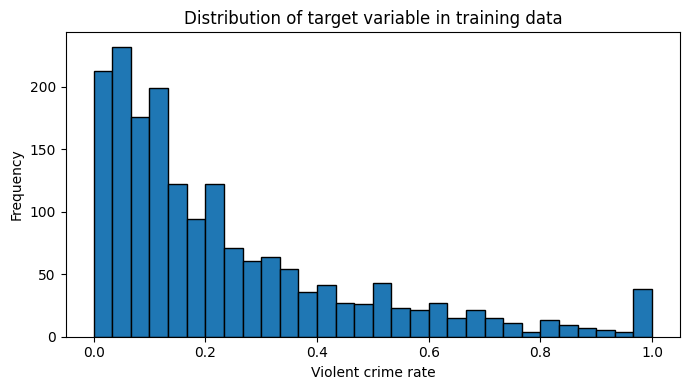


Top 10 features by absolute correlation with target:


,correlation_with_target
c_55,0.741364
c_49,-0.737525
c_48,-0.707464
c_8,-0.691058
c_50,-0.665650
c_51,-0.661464
c_7,0.632003
c_22,0.583338
c_20,-0.581276
c_45,0.561193


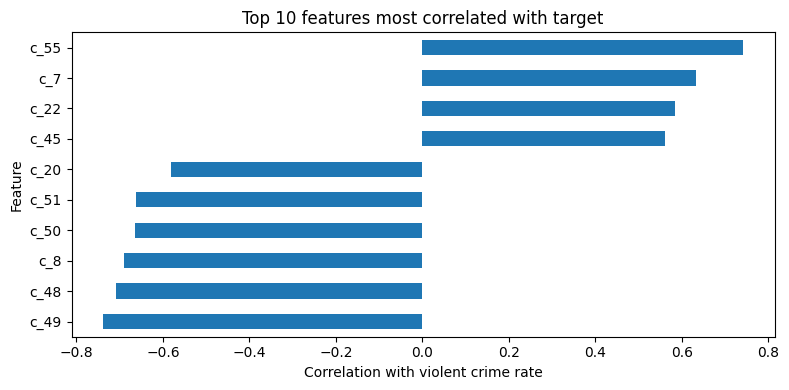

In [7]:
# Perform any EDA as needed. UNGRADED CELL

## Check dataset size and train-test split
print("Full dataset shape:", data.shape)
print("Number of selected features:", len(selected_features))
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

print("\nTarget variable summary:")
display(y_train.describe())

## Check if there are any remaining missing values in selected features
print("\nMissing values in x_train:", x_train.isna().sum().sum())
print("Missing values in x_test:", x_test.isna().sum().sum())
print("Missing values in y_train:", y_train.isna().sum())
print("Missing values in y_test:", y_test.isna().sum())

# Check whether selected features are normalised between 0 and 1
feature_range = pd.DataFrame({
    "min": x_train.min(),
    "max": x_train.max(),
    "mean": x_train.mean(),
    "std": x_train.std()
})

print("\nFeature range summary:")
display(feature_range.describe())

# Plot distribution of target variable
plt.figure(figsize=(7, 4))
plt.hist(y_train, bins=30, edgecolor="black")
plt.xlabel("Violent crime rate")
plt.ylabel("Frequency")
plt.title("Distribution of target variable in training data")
plt.tight_layout()
plt.show()

# Find features with strongest absolute correlation with target
corr_with_target = x_train.corrwith(y_train).sort_values(key=abs, ascending=False)

print("\nTop 10 features by absolute correlation with target:")
display(corr_with_target.head(10).to_frame(name="correlation_with_target"))

# Plot top 10 absolute correlations
top_corr = corr_with_target.head(10)

plt.figure(figsize=(8, 4))
top_corr.sort_values().plot(kind="barh")
plt.xlabel("Correlation with violent crime rate")
plt.ylabel("Feature")
plt.title("Top 10 features most correlated with target")
plt.tight_layout()
plt.show()


### **Question 3**

In this question, you are to build four Lasso and four ridge regression models at different levels of parameter `alpha`, where `alpha` is from 0.001, 0.01, 0.1 and 1, with training data `x_train` and `y_train`.

Calculate the regularised cost function, which is the sum of the MSE, $\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ , on test data and the product of alpha and the model complexity, of each regression model, and explain which are the best Lasso and best ridge regression models.

NOTE: In linear models, the intercept, $w_0$, is usually NOT calculated in the model complexity as the model is expected to capture the mean of the target variable. So the model complexity, $\|w\|_1$ or $\|w\|_2$, should only be calculated from $w_1, w_2, \ldots, w_d$.

HINT: You can use function `numpy.linalg.norm` for both $\|w\|_1$ or $\|w\|_2$.

For each model, calculate 
- the MSE on the test data
- model complexity
- regularised cost

In [8]:
# DO NOT CHANGE THIS CELL
alpha = 10. ** np.arange(-3, 1)

#### 3.1 Lasso

[12 points] Build and report Lasso models.

In [9]:
# TODO: Complete/correct the code as guided by the comments
pdic = {}
for a in alpha:
    model = linear_model.Lasso(alpha=a)
    # fit model on training data
    model.fit(x_train,y_train)


    # predict on test data
    y_pred = model.predict(x_test)
    # compute MSE
    mse = metrics.mean_squared_error(y_test,y_pred)
    # compute complexity
    complexity = np.linalg.norm(model.coef_, ord=1)  ## Lasso regression uses L1 regularization
    # compute regularised cost
    reg_cost = mse + a * complexity

    pdic[f'alpha={a}'] = [mse, complexity, reg_cost]

pd.DataFrame(pdic, index=['MSE on test data', 'model complexity', 'regularised cost'])

,alpha=0.001,alpha=0.01,alpha=0.1,alpha=1.0
MSE on test data,0.021386,0.030384,0.062445,0.062445
model complexity,1.294376,0.623790,0.000000,0.000000
regularised cost,0.022680,0.036622,0.062445,0.062445


[2 points] Which Lasso regression model will you choose and why?

:

**TODO**: Your answer

I would choose the model with 'alpha=0.001' because it has the lowest mean squared error (MSE) on the test data among the models compared. This indicates that the model has the best predictive accuracy on unseen data.

It also has the lowest regularised cost. Since regularised cost is a function of both MSE and model complexity, a lower regularised cost suggests that the model offers the best trade-off between test performance and model simplicity.

Although the model complexity is higher for 'alpha = 0.001', its regularised cost is still the lowest because the penalty term is small at this alpha value. Therefore, 'alpha = 0.001' is the most suitable Lasso regression model among the models compared.


:

#### 3.2 Ridge

[12 points] Build and report Ridge models.

In [10]:
# TODO: Follow the example from Lasso and adjust accordingly for Ridge regression
pdic = {}
for a in alpha:
    model = linear_model.Ridge(alpha=a)
    # fit model on training data
    model.fit(x_train, y_train)
    # predict on test data
    y_pred = model.predict(x_test)
    # compute MSE
    mse = metrics.mean_squared_error(y_test, y_pred)
    # compute complexity — L2 norm of weights, excluding intercept
    complexity = np.linalg.norm(model.coef_, ord=2)  # Ridge regression uses L2 regularization
    # compute regularised cost
    reg_cost = mse + a * complexity

    pdic[f'alpha={a}'] = [mse, complexity, reg_cost]

pd.DataFrame(pdic, index=['MSE on test data', 'model complexity', 'regularised cost'])

,alpha=0.001,alpha=0.01,alpha=0.1,alpha=1.0
MSE on test data,0.019226,0.019236,0.019284,0.019520
model complexity,1.764676,1.685596,1.336402,0.799728
regularised cost,0.020991,0.036092,0.152924,0.819248


[2 points] Which Ridge regression model will you choose and why?

:

**TODO**: Your answer

I would choose the Ridge regression model with 'alpha = 0.001' because it has the lowest mean squared error (MSE) on the test data among the Ridge models compared. This may indicate that the model has the best predictive accuracy on unseen data.

It also has the lowest regularised cost. Since regularised cost is a function of both MSE and model complexity, a model with a lower regularised cost offers the best trade-off between test performance and model simplicity.

Although the model complexity is higher for 'alpha = 0.001', its regularised cost is still the lowest because the penalty term is small at this alpha value. Therefore, 'alpha = 0.001' is the most suitable Ridge regression model among the models compared.


:

#### 3.3 Visualise

[6 points] Please choose one model from the 8 models above and select two attributes to visualise the regression models with greyscale contours on the target value, choose darker color for higher value. Please label the axis with the names of the attributes and specify tick values.

Top 2 features: c_49 (coef=-0.2196), c_55 (coef=+0.2143)


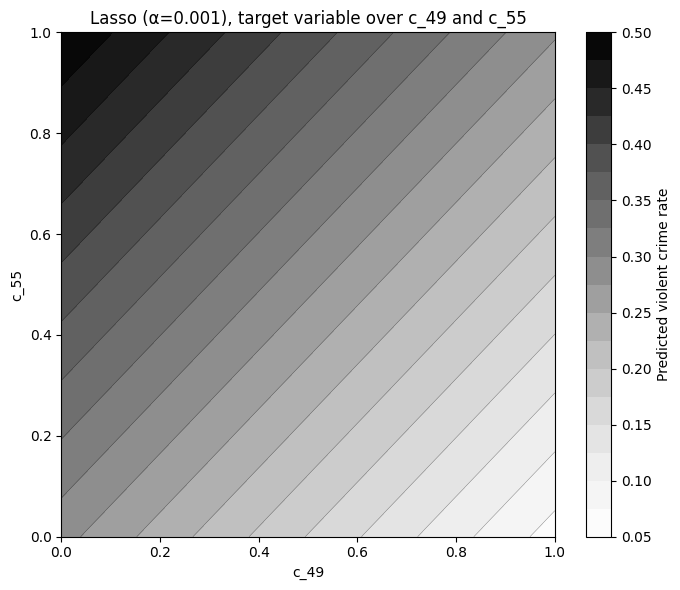

In [11]:
# TODO: Code out your solution and make sure the chart output is presented
## Lasso regression is picked for visualization because it selects features by shrinking coefficients to 0, 
## making the model easier to intepret, as non-zero coefficients are the features the model considers important.

best_model = linear_model.Lasso(alpha=0.001).fit(x_train, y_train)  

coefs = pd.Series(best_model.coef_, index=x_train.columns)
top2 = coefs.abs().sort_values(ascending=False).head(2).index.tolist()
feat_1, feat_2 = top2[0], top2[1]
print(f'Top 2 features: {feat_1} (coef={coefs[feat_1]:+.4f}), '
      f'{feat_2} (coef={coefs[feat_2]:+.4f})')


n_grid = 50
a_grid = np.linspace(x_train[feat_1].min(), x_train[feat_1].max(), n_grid)
b_grid = np.linspace(x_train[feat_2].min(), x_train[feat_2].max(), n_grid)
A, B = np.meshgrid(a_grid, b_grid)

X_pred = pd.DataFrame(np.tile(x_train.median().values, (n_grid * n_grid, 1)), ## fixing other features at median
                      columns=x_train.columns)
X_pred[feat_1] = A.ravel()
X_pred[feat_2] = B.ravel()
Z = best_model.predict(X_pred).reshape(n_grid, n_grid)


fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(A, B, Z, levels=20, cmap='Greys') ## greyscale contours
ax.contour(A, B, Z, levels=20, colors='k', linewidths=0.3, alpha=0.5)
cbar = plt.colorbar(cs, ax=ax)
cbar.set_label('Predicted violent crime rate')

ax.set_xlabel(f'{feat_1}')
ax.set_ylabel(f'{feat_2}')
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_title(f'Lasso (α=0.001), target variable over {feat_1} and {feat_2}')
plt.tight_layout()
plt.show()

[4 points] Explain your strategy about attribute selection.

:

**TODO**: Your answer

For the contour plot, I used the Lasso regression model with 'alpha = 0.001'. Although Ridge regression produced a slightly lower MSE, Lasso is more suitable for this visualisation because it performs feature selection by shrinking some coefficients to zero. This makes it easier to identify which attributes the model relies on more strongly.

'c_49' and 'c_55' were selected because they have the largest absolute coefficient values in the chosen Lasso model. In a linear model, the size of a coefficient indicates how strongly that feature affects the predicted target, assuming the other features are held constant. Since normalization was performed on the features in this dataset, the coefficients can be compared more fairly.

For the contour plot, I varied only these two selected features across their observed ranges. All other features were fixed at their training-set median values. This allows the plot to show how the predicted crime rate changes with 'c_49' and 'c_55', while keeping the remaining community attributes at their median values. The resulting plot is a two-feature grid for the selected Lasso model. The darker regions represent higher predicted crime rates, while the lighter regions represent lower predicted crime rates.

:

### **Question 4** Low/Medium/High Crime Rate Prediction

In this question, we wish to explore further on the same dataset. We first label each row as low, medium or high crime rate by the following two expressions:

In [12]:
# DO NOT CHANGE THIS CELL
y_train_c = np.array([0 if i < .1 else 1 if i < .26 else 2 for i in y_train])
y_test_c = np.array([0 if i < .1 else 1 if i < .26 else 2 for i in y_test])

,Training count,Test count
Class 0: Low crime,621,58
Class 1: Medium crime,587,75
Class 2: High crime,586,67


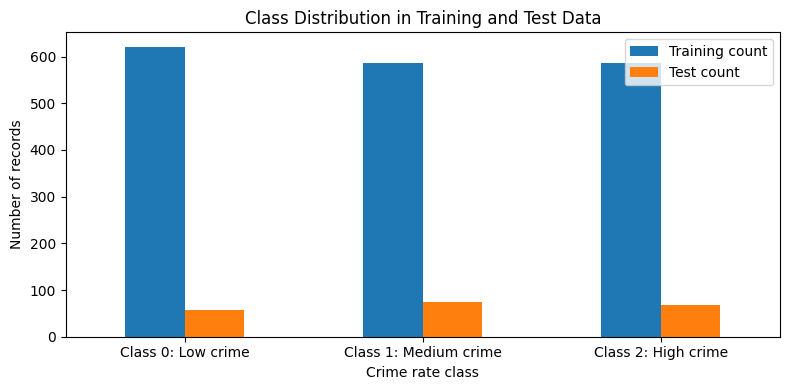

In [13]:
# Perform any EDA as needed. UNGRADED CELL

# Check the class distribution after converting the target into 3 classes
train_class_counts = pd.Series(y_train_c).value_counts().sort_index()
test_class_counts = pd.Series(y_test_c).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Training count": train_class_counts,
    "Test count": test_class_counts
})

class_distribution.index = ["Class 0: Low crime", "Class 1: Medium crime", "Class 2: High crime"]

display(class_distribution)

# Plot class distribution
class_distribution.plot(kind="bar", figsize=(8, 4))
plt.title("Class Distribution in Training and Test Data")
plt.xlabel("Crime rate class")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This is to assign class 0 to records with crime rate less than 0.1, assign class 1 to records with crime rate greater than or equal to 0.1 and less than 0.26, and assign class 2 to those with crime rate greater than or equal to 0.26.

Your task is to build a 3-class classification model from the training data, and validate it with the test data.

[5 points] Build a logistic regression model with C=10 and max_iter=10000 and other parameters at default choices. By default, logistic regression uses option 'auto' for multiclass classification, which means, 'auto' selects 'ovr' if the data is binary, or if solver='liblinear', and otherwise selects 'multinomial'.

[9 points] Build a confusion matrix for the logistic regression model. Each row of the confusion matrix represents an actual class, each column of the confusion matrix represents a predicted class, and the value of the cell at row $i$ and column $j$ is the number of instances which is actually class $i$, but predicted as class $j$.

Desired output:

|                | Predicted Class = 0 | Predicted Class = 1 | Predicted Class = 2 |
|----------------|---------------------|---------------------|---------------------|
| Actual Class = 0 |    |    |    |
| Actual Class = 1 |    |    |    |
| Actual Class = 2 |    |    |    |

<p style='font-size: small'>Pandas dataframe can render the confusion matrix as above.</p>

[1 point] There is a `score` method for the classifier. What is the `score` of the logistic regression model on `x_test` and `y_test_c`? What does it mean?

In [40]:
# TODO
# Build the logistic regression model

log_reg = linear_model.LogisticRegression(C=10, max_iter= 10000)
log_reg.fit(x_train, y_train_c)
y_pred_c = log_reg.predict(x_test)

# Output the confusion matrix
cmatrix = metrics.confusion_matrix(y_test_c, y_pred_c, labels=[0, 1, 2])

cmatrix_df = pd.DataFrame(
    cmatrix,
    index=["Actual Class = 0", "Actual Class = 1", "Actual Class = 2"],
    columns=["Predicted Class = 0", "Predicted Class = 1", "Predicted Class = 2"]
)

display(cmatrix_df)
# Print score and explain what it means
score = log_reg.score(x_test, y_test_c)
print("Score on test data:", score)
print(f"This score represents the overall classification accuracy on the test data, i.e., it indicates that {score*100:.2f}% of the test records were correctly classified.")


,Predicted Class = 0,Predicted Class = 1,Predicted Class = 2
Actual Class = 0,44,13,1
Actual Class = 1,20,41,14
Actual Class = 2,1,14,52


Score on test data: 0.685
This score represents the overall classification accuracy on the test data, i.e., it indicates that 68.50% of the test records were correctly classified.


[4 points] Explain whether `score` is the appropriate evaluation metric. If not, suggest an alternative evaluation metric (calculation not needed) and explain.

:

**TODO**: Your answer

In this case, the overall classification accuracy is reasonably appropriate because the three classes are fairly balanced in the test set with Class 0 having 58 observations, Class 1 having 75 observations, and Class 2 having 67 observations. Hence, the score is not overly dominated by one majority class.

However, accuracy alone may not be the most appropriate evaluation metric. Since the classes represent low, medium and high crime rates, it may be more important to correctly identify the high-crime class. Failing to detect an actual high-crime community may be more damaging than misclassifying it.

Therefore, an alternative evaluation metric would be recall for `Class 2: High-crime`. Class 2 recall measures the proportion of actual high-crime communities that are correctly classified as high crime. This would be useful because it focuses specifically on reducing false negatives for the class.


:

[6 points] In this exercise, you are to visualise the change of training error and test error in response to the change of complexity trade-off parameter C. Note that logistic regression actually maximises the log likelihood. With the convention that cost function is usually a minimization function, you may want to plot the negative log likelihood as training error or test error, i.e., $-\sum \ln \big( p(y_i \mid x_i, w) \big)$. 

Note that if 'ovr' is used for multi_class, the sum of the three probabilities of $x_i$ may not be one. Therefore, multi_class = 'multinomial' and solver = 'newton-cg' should be chosen to give the correct $p(y_i |x_i,w)$. Please visualise both the training error and test error. There should be two lines in the figure, a blue line represents the training error, and a red line represents the test error. The training error and test error should change with each of the ten trade-off parameters from $10^{-3}$ to $10^6$.

- The requested output is a single chart.
- Organise your chart to ensure clear visualisation and effective communication, using descriptive title, well-labeled axes, and annotations where appropriate.

In [15]:
# DO NOT CHANGE THIS CELL
complexity = 10. ** np.arange(-3, 7)

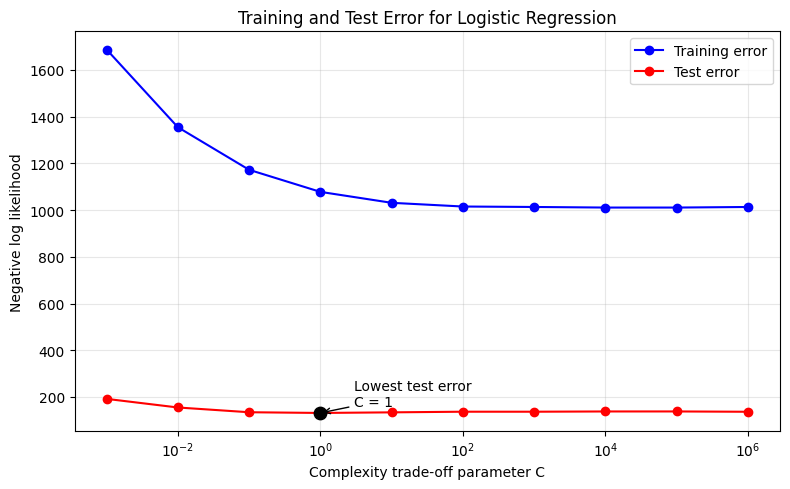

,C,Training error,Test error
0,0.001,1687.640246,191.925419
1,0.010,1354.996543,155.100124
2,0.100,1172.623168,134.736931
3,1.000,1078.148487,131.694318
4,10.000,1031.319232,134.245581
5,100.000,1015.453442,137.017731
6,1000.000,1013.492288,136.983540
7,10000.000,1011.026343,138.062495
8,100000.000,1011.024373,138.125927
9,1000000.000,1013.452054,136.784602


In [16]:
train_errors = []
test_errors = []

for c in complexity:
    log_reg_model = linear_model.LogisticRegression(
        C=c,
        max_iter=10000,
        solver="newton-cg"
    )
    
    log_reg_model.fit(x_train, y_train_c)
    
    train_proba = log_reg_model.predict_proba(x_train)
    test_proba = log_reg_model.predict_proba(x_test)
    
    train_error = metrics.log_loss(
        y_train_c,
        train_proba,
        labels=[0, 1, 2],
        normalize=False
    )
    
    test_error = metrics.log_loss(
        y_test_c,
        test_proba,
        labels=[0, 1, 2],
        normalize=False
    )
    
    train_errors.append(train_error)
    test_errors.append(test_error)

## Find the best C based on the lowest test error
best_index = np.argmin(test_errors)
best_c = complexity[best_index]
best_test_error = test_errors[best_index]

plt.figure(figsize=(8, 5))

plt.plot(
    complexity,
    train_errors,
    marker="o",
    color="blue",
    label="Training error"
)

plt.plot(
    complexity,
    test_errors,
    marker="o",
    color="red",
    label="Test error"
)

# Annotation for best C
plt.scatter(
    best_c,
    best_test_error,
    color="black",
    s=80,
    zorder=5
)

plt.annotate(
    f"Lowest test error\nC = {best_c:g}",
    xy=(best_c, best_test_error),
    xytext=(best_c * 3, best_test_error + 30),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.xscale("log")
plt.xlabel("Complexity trade-off parameter C")
plt.ylabel("Negative log likelihood")
plt.title("Training and Test Error for Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

error_df = pd.DataFrame({
    "C": complexity,
    "Training error": train_errors,
    "Test error": test_errors
})

display(error_df)

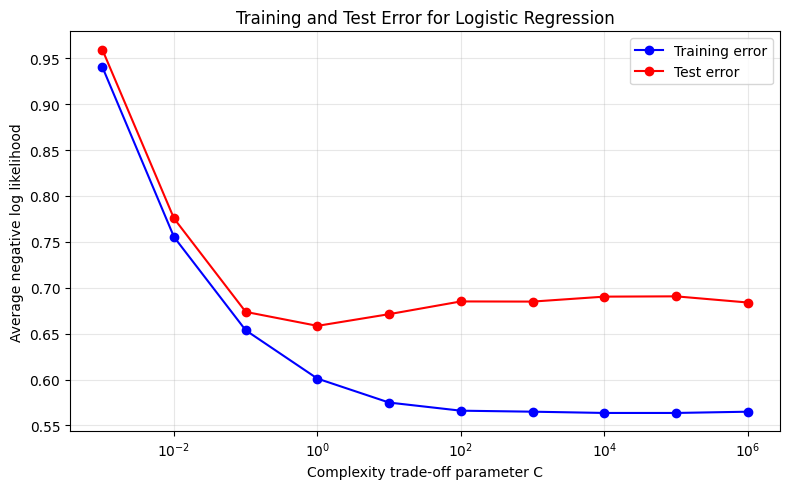

,C,Training error,Test error
0,0.001,0.940714,0.959627
1,0.010,0.755294,0.775501
2,0.100,0.653636,0.673685
3,1.000,0.600975,0.658472
4,10.000,0.574871,0.671228
5,100.000,0.566028,0.685089
6,1000.000,0.564934,0.684918
7,10000.000,0.563560,0.690312
8,100000.000,0.563559,0.690630
9,1000000.000,0.564912,0.683923


In [18]:
train_errors = []
test_errors = []

for c in complexity:
    clf = linear_model.LogisticRegression(
        C=c,
        max_iter=10000,
        solver="newton-cg"
    )
    
    clf.fit(x_train, y_train_c)
    
    train_proba = clf.predict_proba(x_train)
    test_proba = clf.predict_proba(x_test)
    
    train_error = metrics.log_loss(
        y_train_c,
        train_proba,
        labels=[0, 1, 2]
    )
    
    test_error = metrics.log_loss(
        y_test_c,
        test_proba,
        labels=[0, 1, 2]
    )
    
    train_errors.append(train_error)
    test_errors.append(test_error)

plt.figure(figsize=(8, 5))
plt.plot(complexity, train_errors, marker="o", color="blue", label="Training error")
plt.plot(complexity, test_errors, marker="o", color="red", label="Test error")

plt.xscale("log")
plt.xlabel("Complexity trade-off parameter C")
plt.ylabel("Average negative log likelihood")
plt.title("Training and Test Error for Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

error_df = pd.DataFrame({
    "C": complexity,
    "Training error": train_errors,
    "Test error": test_errors
})

display(error_df)

[4 points] Please explain the chart.

:

**TODO**: Your answer

The chart shows the training and test errors for different values of the complexity trade-off parameter 'C'. In logistic regression, a smaller 'C' means stronger regularisation, while a larger 'C' means weaker regularisation and a more complex model.

As 'C' increases, the training error generally decreases. This is expected because weaker regularisation allows the model to fit the training data more closely.

The test error decreases from 'C' = 0.001 to 'C' = 1.0, suggesting that very small values of 'C' may cause the model to underfit. The lowest test error occurs at 'C' = 1.0, so this is the best value of 'C' among the values tested. After 'C' = 1.0, the test error increases slightly, even though the training error continues to decrease. This suggests that increasing model complexity beyond this point may lead to some overfitting.

Since the negative log likelihood is calculated as a summation, the training error is naturally larger than the test error because the training set contains more observations. Therefore, the absolute values of the training and test errors should not be compared directly. The main focus should be on the trend of each line and the point where the test error is lowest.

:

---

### **Question 5**

This is a competition, hosted on Kaggle Platform. Your task is to develop a machine learning model to distinguish bot users from genuine users based on a given dataset of Twitter accounts. This competition will give you hands-on experience with data preprocessing, feature engineering, model training, and evaluation.

Please join the competition and follow the instructions there.

https://www.kaggle.com/t/d82a009b21e8436685e9abcbb1932ff5

<p style='font-size:small'>This question is not meant to be answered in this notebook.</p>